# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
try:
  import google.colab
  RUN_ENV = 'colab'
except ImportError:
  RUN_ENV = 'local'

In [5]:
COLAB_KAGGLE_UTILS_PATH = '/content/drive/MyDrive/KaggleData'
LOCAL_KAGGLE_UTILS_PATH = '/home/sameera/Projects'

In [ ]:
import sys

if RUN_ENV == 'colab':
    sys.path.append(COLAB_KAGGLE_UTILS_PATH)
    dataPath = '/content/drive/MyDrive/KaggleData/s6e7/'
else:
    sys.path.append(LOCAL_KAGGLE_UTILS_PATH)
    dataPath = '/home/sameera/Projects/Kaggle/data/KaggleData/s6e7/'

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Custom utilities
from kaggle_utils.data.visualiser import DataVisualizer

In [8]:
train = pd.read_csv(dataPath + 'train.csv', low_memory=False)
test = pd.read_csv(dataPath + 'test.csv', low_memory=False)
sample_submission = pd.read_csv(dataPath + 'sample_submission.csv', index_col='id', low_memory=False)

# Data glimpse

In [3]:
train.shape, test.shape, sample_submission.shape

((690088, 15), (295753, 14), (295753, 1))

In [4]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [5]:
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [6]:
sample_submission.head()

,health_condition
id,
690088,at-risk
690089,at-risk
690090,at-risk
690091,at-risk
690092,at-risk


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       295753 non-null  int64  
 1   sleep_duration           263182 non-null  float64
 2   heart_rate               292396 non-null  float64
 3   bmi                      289797 non-null  float64
 4   calorie_expenditure      273101 non-null  float64
 5   step_count               289789 non-null  float64
 6   exercise_duration        292795 non-null  float64
 7   water_intake             277120 non-null  float64
 8   diet_type                292795 non-null  object 
 9   stress_level             260263 non-null  object 
 10  sleep_quality            270754 non-null  object 
 11  physical_activity_level  280058 non-null  object 
 12  smoking_alcohol          283504 non-null  object 
 13  gender                   286593 non-null  object 
dtypes: f

# Data stats

In [15]:
visualiser = DataVisualizer(train, test)

In [16]:
visualiser.get_stats()

,count,mean,std,min,25%,50%,75%,max
id,690088.000000,345043.500000,199211.390620,0.000000,172521.750000,345043.500000,517565.250000,690087.000000
sleep_duration,614089.000000,6.992597,1.215407,3.000000,6.160000,6.990000,7.810000,10.000000
heart_rate,682255.000000,75.096504,8.175106,50.000000,69.400000,75.100000,80.700000,107.700000
bmi,676190.000000,22.984925,2.481787,16.000000,21.320000,22.990000,24.660000,34.820000
calorie_expenditure,637235.000000,2226.084931,347.532098,1200.000000,2053.000000,2241.000000,2456.000000,3580.000000
step_count,676172.000000,8615.953050,3929.399831,1002.000000,5389.000000,8856.000000,12114.000000,14999.000000
exercise_duration,683187.000000,38.751456,14.742189,0.000000,29.200000,39.400000,49.400000,99.800000
water_intake,646611.000000,2.188542,0.518489,0.500000,1.840000,2.170000,2.500000,4.720000


In [24]:
visualiser.get_stats('train')

,count,mean,std,min,25%,50%,75%,max
id,690088.000000,345043.500000,199211.390620,0.000000,172521.750000,345043.500000,517565.250000,690087.000000
sleep_duration,614089.000000,6.992597,1.215407,3.000000,6.160000,6.990000,7.810000,10.000000
heart_rate,682255.000000,75.096504,8.175106,50.000000,69.400000,75.100000,80.700000,107.700000
bmi,676190.000000,22.984925,2.481787,16.000000,21.320000,22.990000,24.660000,34.820000
calorie_expenditure,637235.000000,2226.084931,347.532098,1200.000000,2053.000000,2241.000000,2456.000000,3580.000000
step_count,676172.000000,8615.953050,3929.399831,1002.000000,5389.000000,8856.000000,12114.000000,14999.000000
exercise_duration,683187.000000,38.751456,14.742189,0.000000,29.200000,39.400000,49.400000,99.800000
water_intake,646611.000000,2.188542,0.518489,0.500000,1.840000,2.170000,2.500000,4.720000


In [17]:
visualiser.get_summary('train')

,dtypes,missing#,missing%,uniques,count
id,int64,0,0.000000,690088,690088
health_condition,object,0,0.000000,3,690088
sleep_duration,float64,75999,11.012943,701,614089
heart_rate,float64,7833,1.135073,537,682255
bmi,float64,13898,2.013946,1596,676190
calorie_expenditure,float64,52853,7.658878,2101,637235
step_count,float64,13916,2.016554,12807,676172
exercise_duration,float64,6901,1.000017,856,683187
water_intake,float64,43477,6.300211,400,646611
diet_type,object,6901,1.000017,3,683187


In [18]:
visualiser.get_summary('test')

,dtypes,missing#,missing%,uniques,count
id,int64,0,0.000000,690088,690088
health_condition,object,0,0.000000,3,690088
sleep_duration,float64,75999,11.012943,701,614089
heart_rate,float64,7833,1.135073,537,682255
bmi,float64,13898,2.013946,1596,676190
calorie_expenditure,float64,52853,7.658878,2101,637235
step_count,float64,13916,2.016554,12807,676172
exercise_duration,float64,6901,1.000017,856,683187
water_intake,float64,43477,6.300211,400,646611
diet_type,object,6901,1.000017,3,683187


# Features

In [19]:
conts = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure','step_count', 'exercise_duration', 'water_intake']
cats = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level','smoking_alcohol', 'gender']

target = 'health_condition'

# Data visualizing

## Continous columns test vs train

/home/sameera/Projects/kaggle_utils/data/visualiser.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


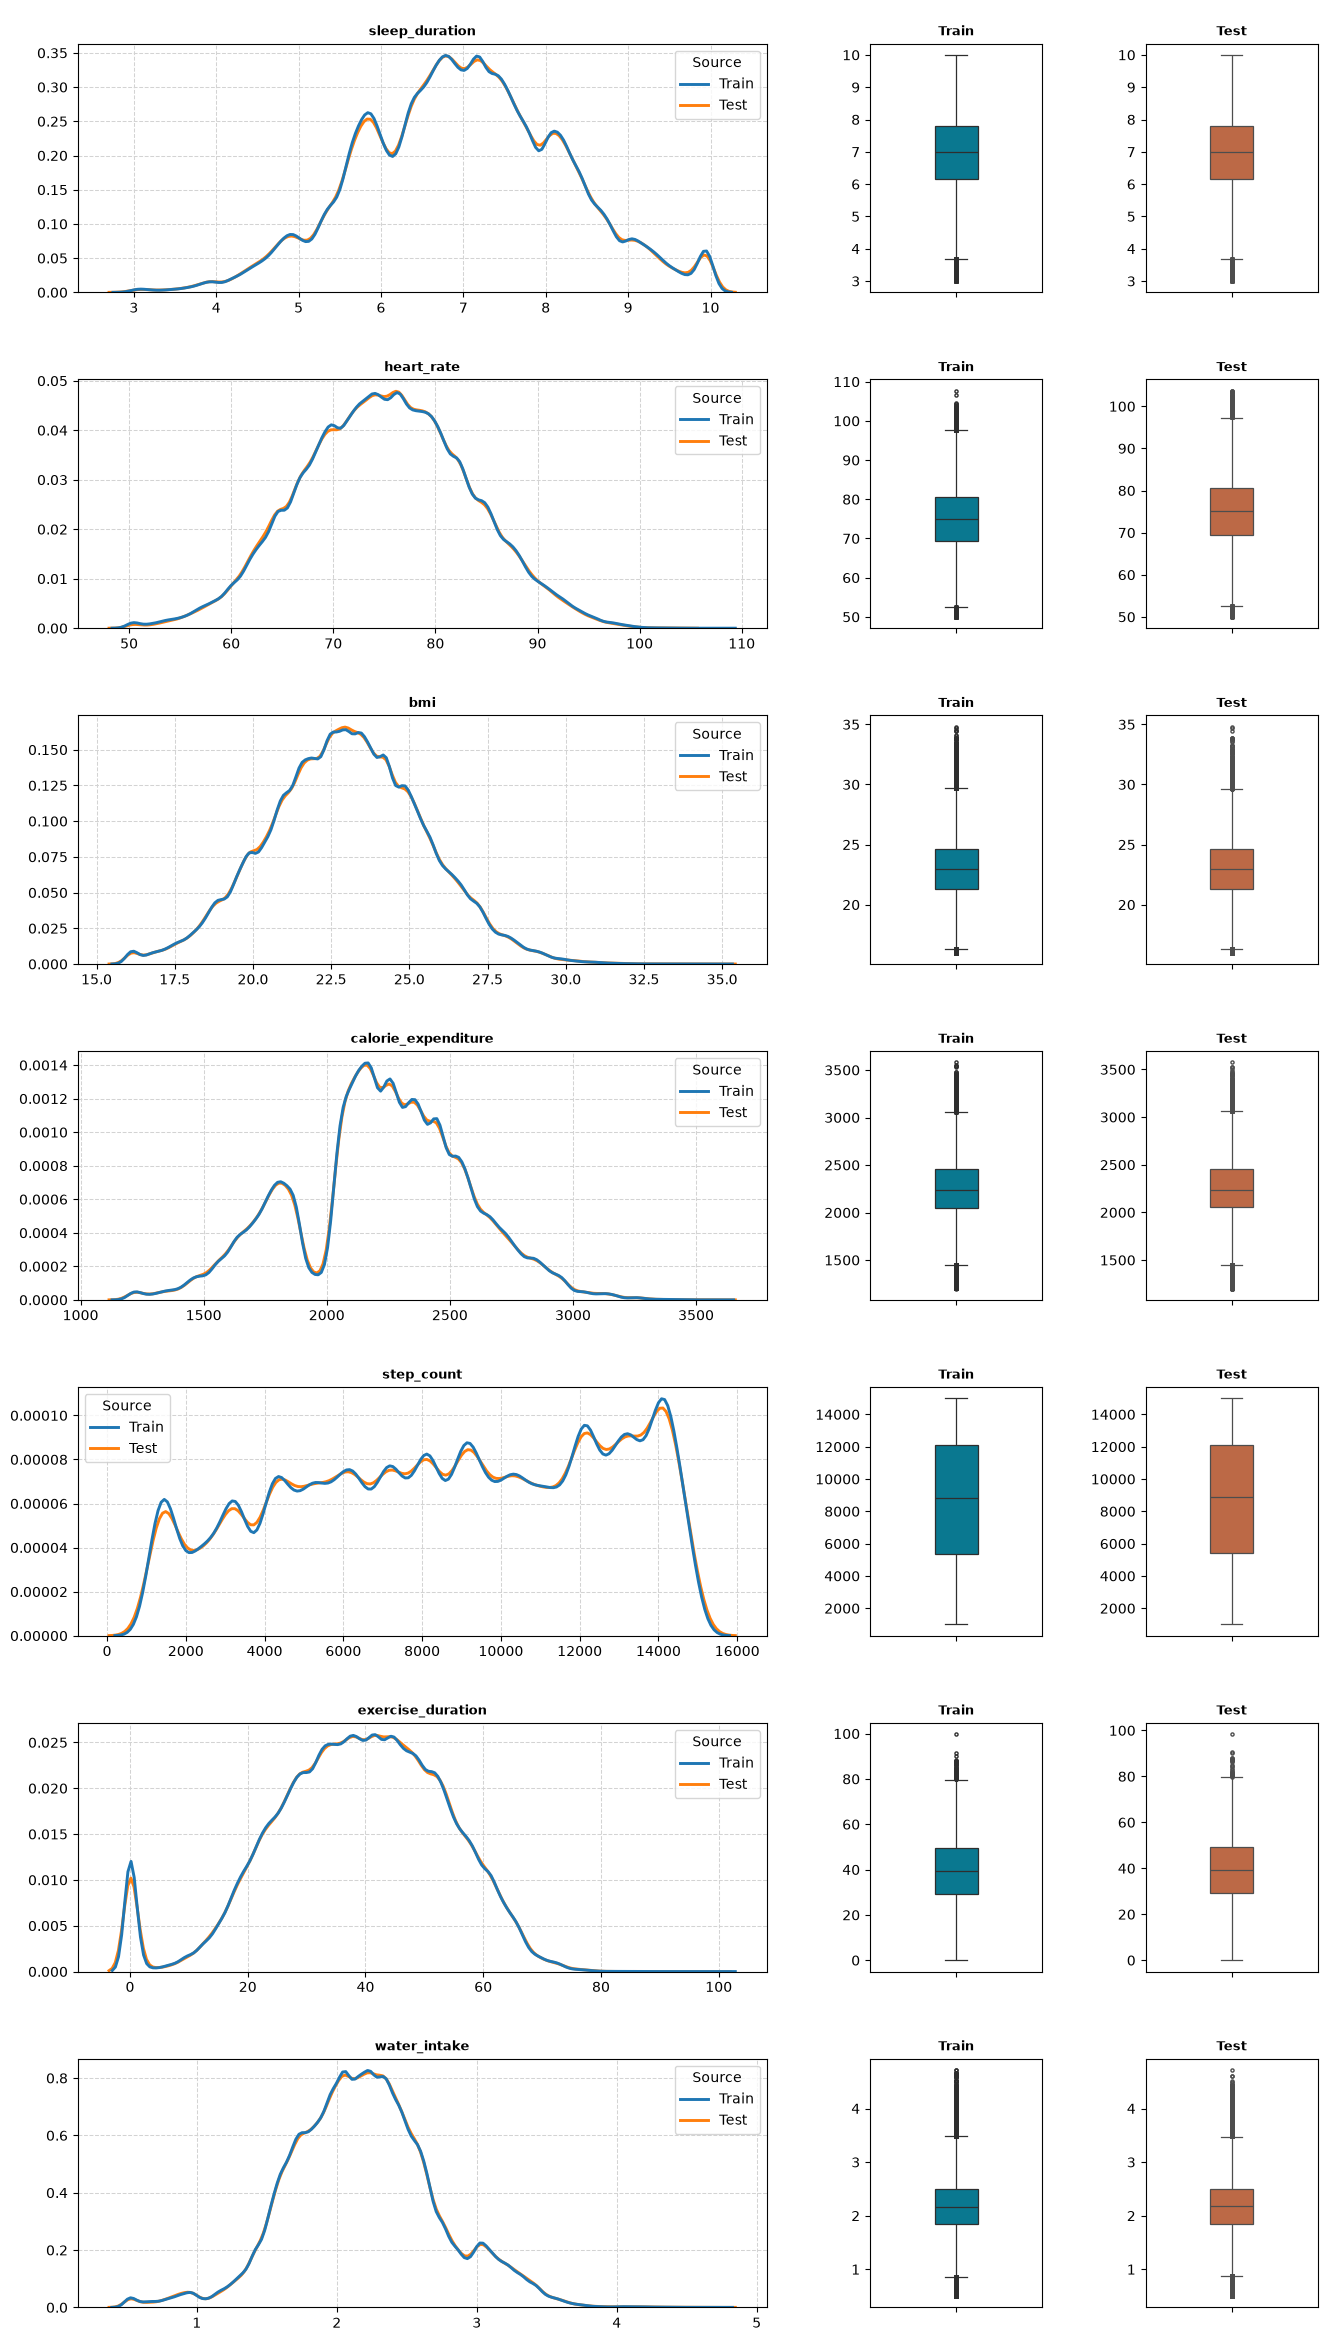

In [20]:
visualiser.plot_train_test_continuous(conts, common_norm = False) # toggle common norm to True to get the same area under the curve for both train and test (True; train+test=1, False; train=1, test=1)

## Train cont vs target

/home/sameera/Projects/kaggle_utils/data/visualiser.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


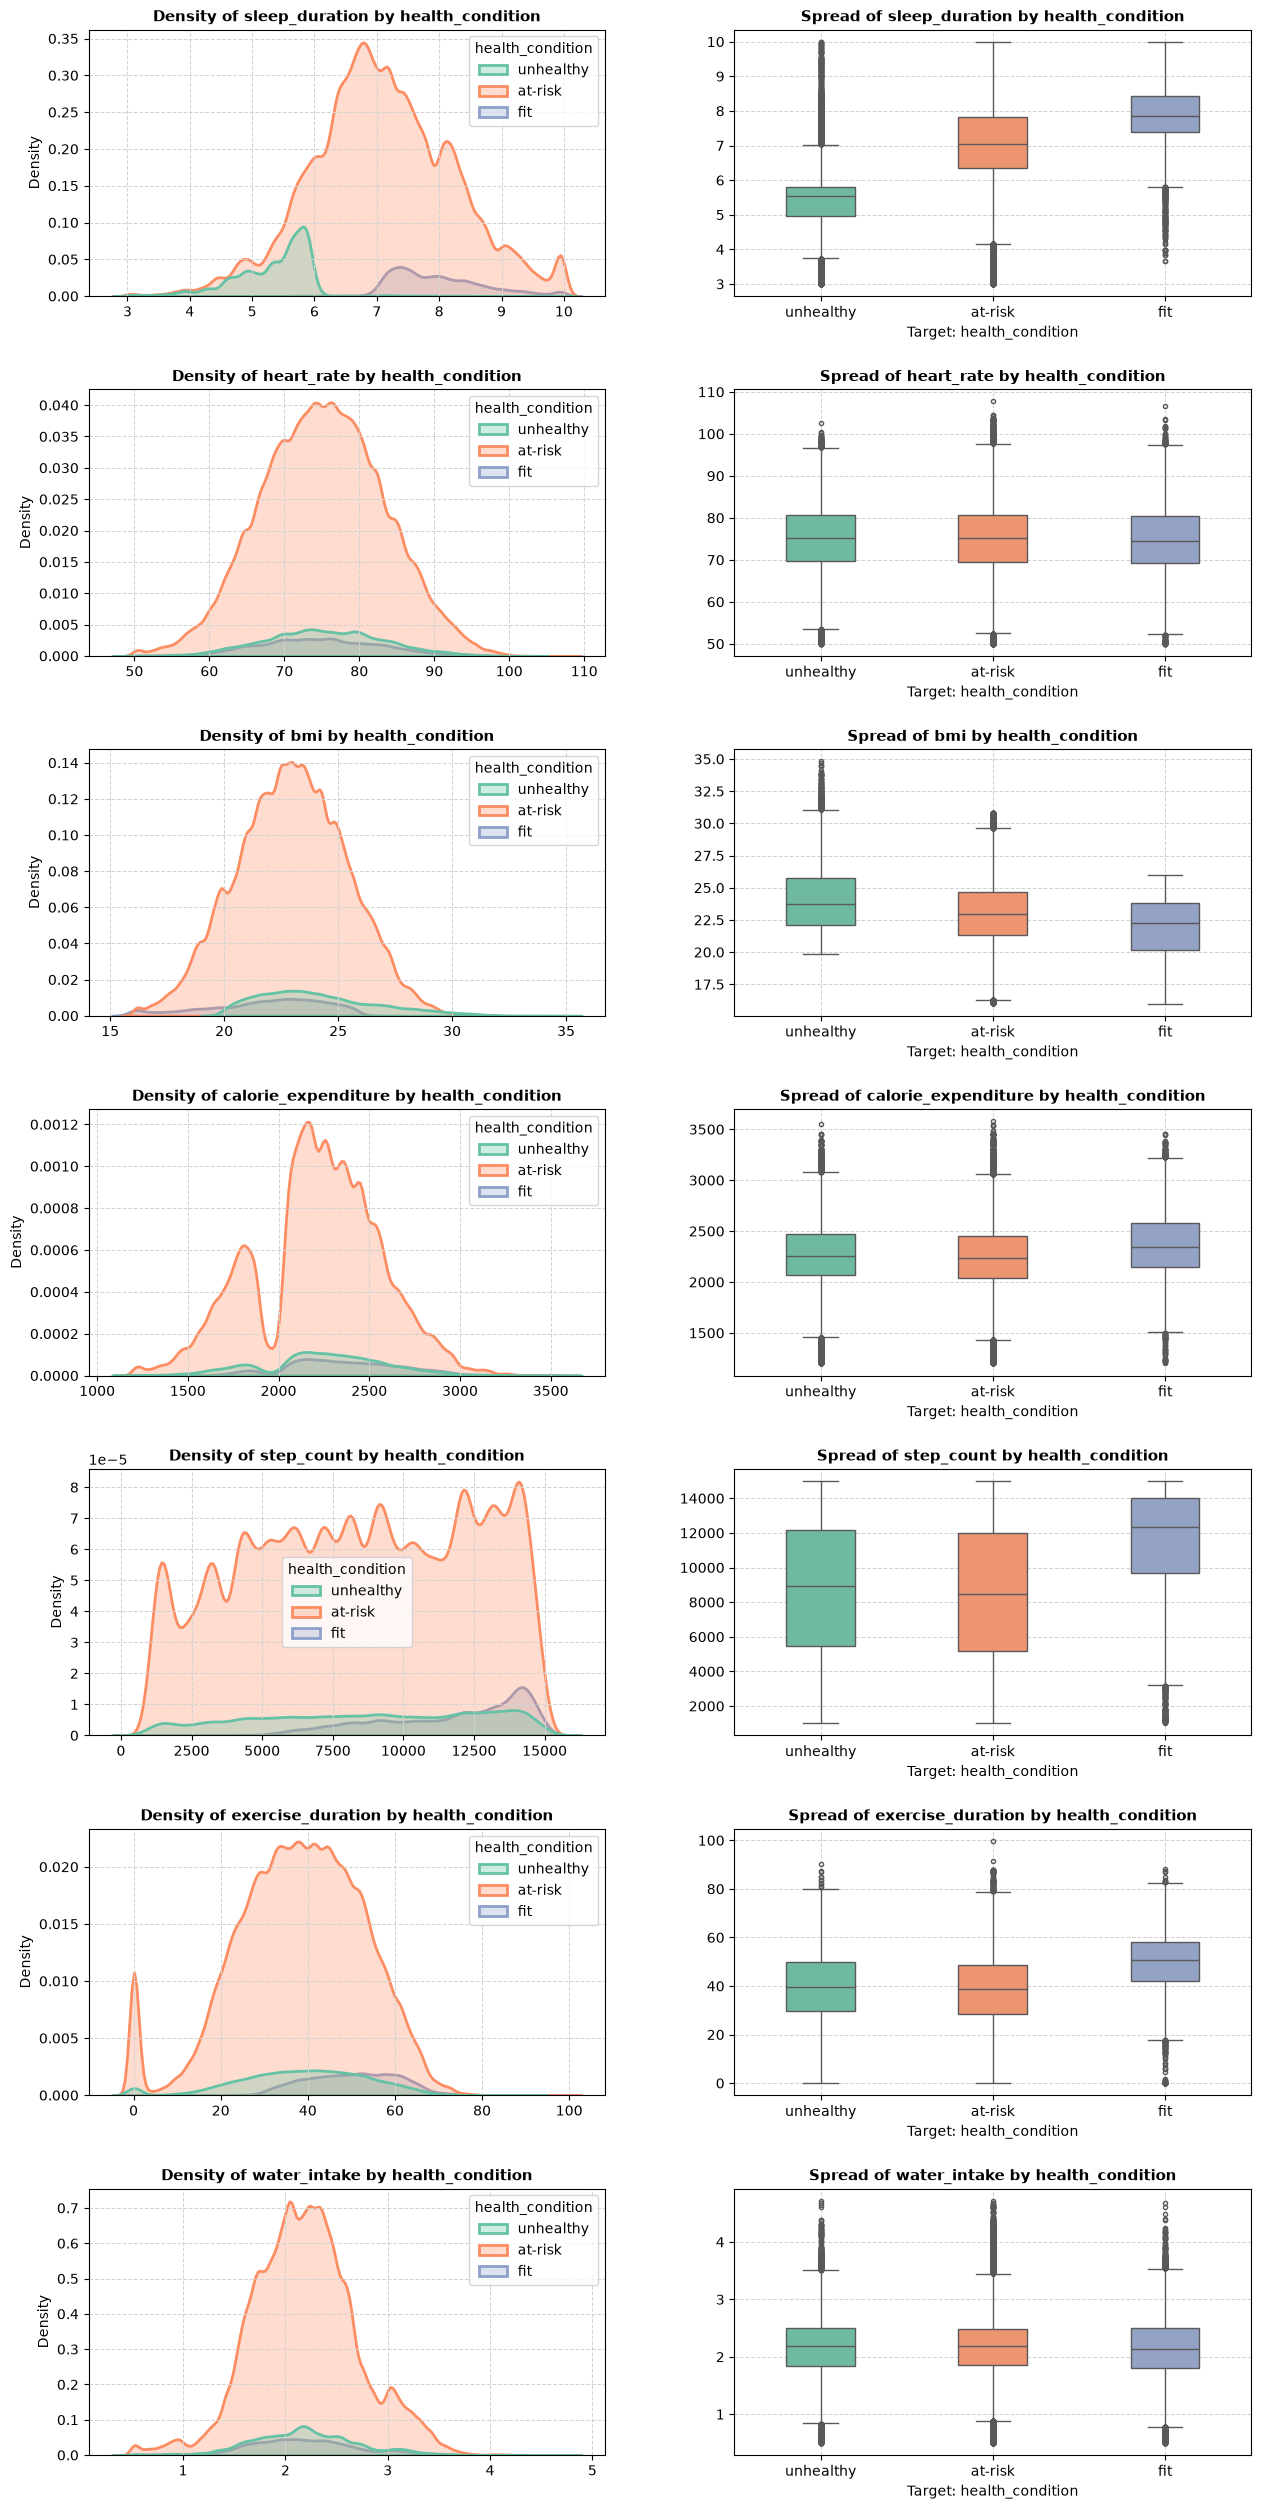

In [21]:
visualiser.plot_continuous_vs_target(conts, target, common_norm = True) # toggle common norm to True to get the same area under the curve for both train and test (True; train+test=1, False; train=1, test=1)

## Categorical train vs test

/home/sameera/Projects/kaggle_utils/data/visualiser.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


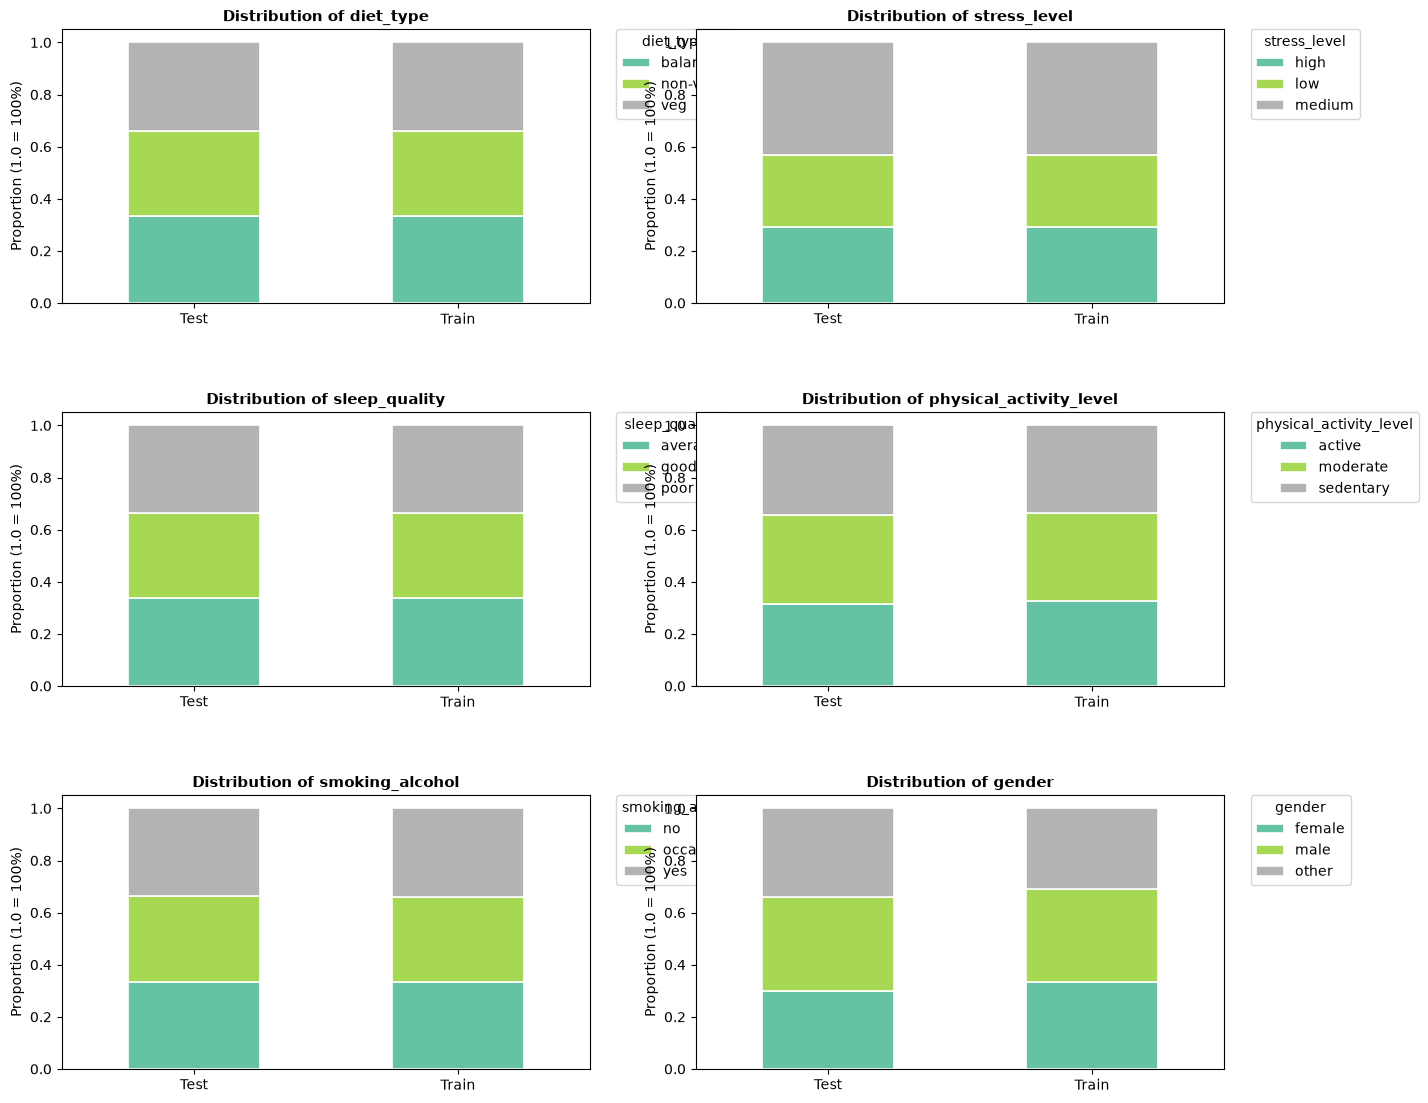

In [22]:
visualiser.plot_categorical_proportions(cats)

## Categorical vs target

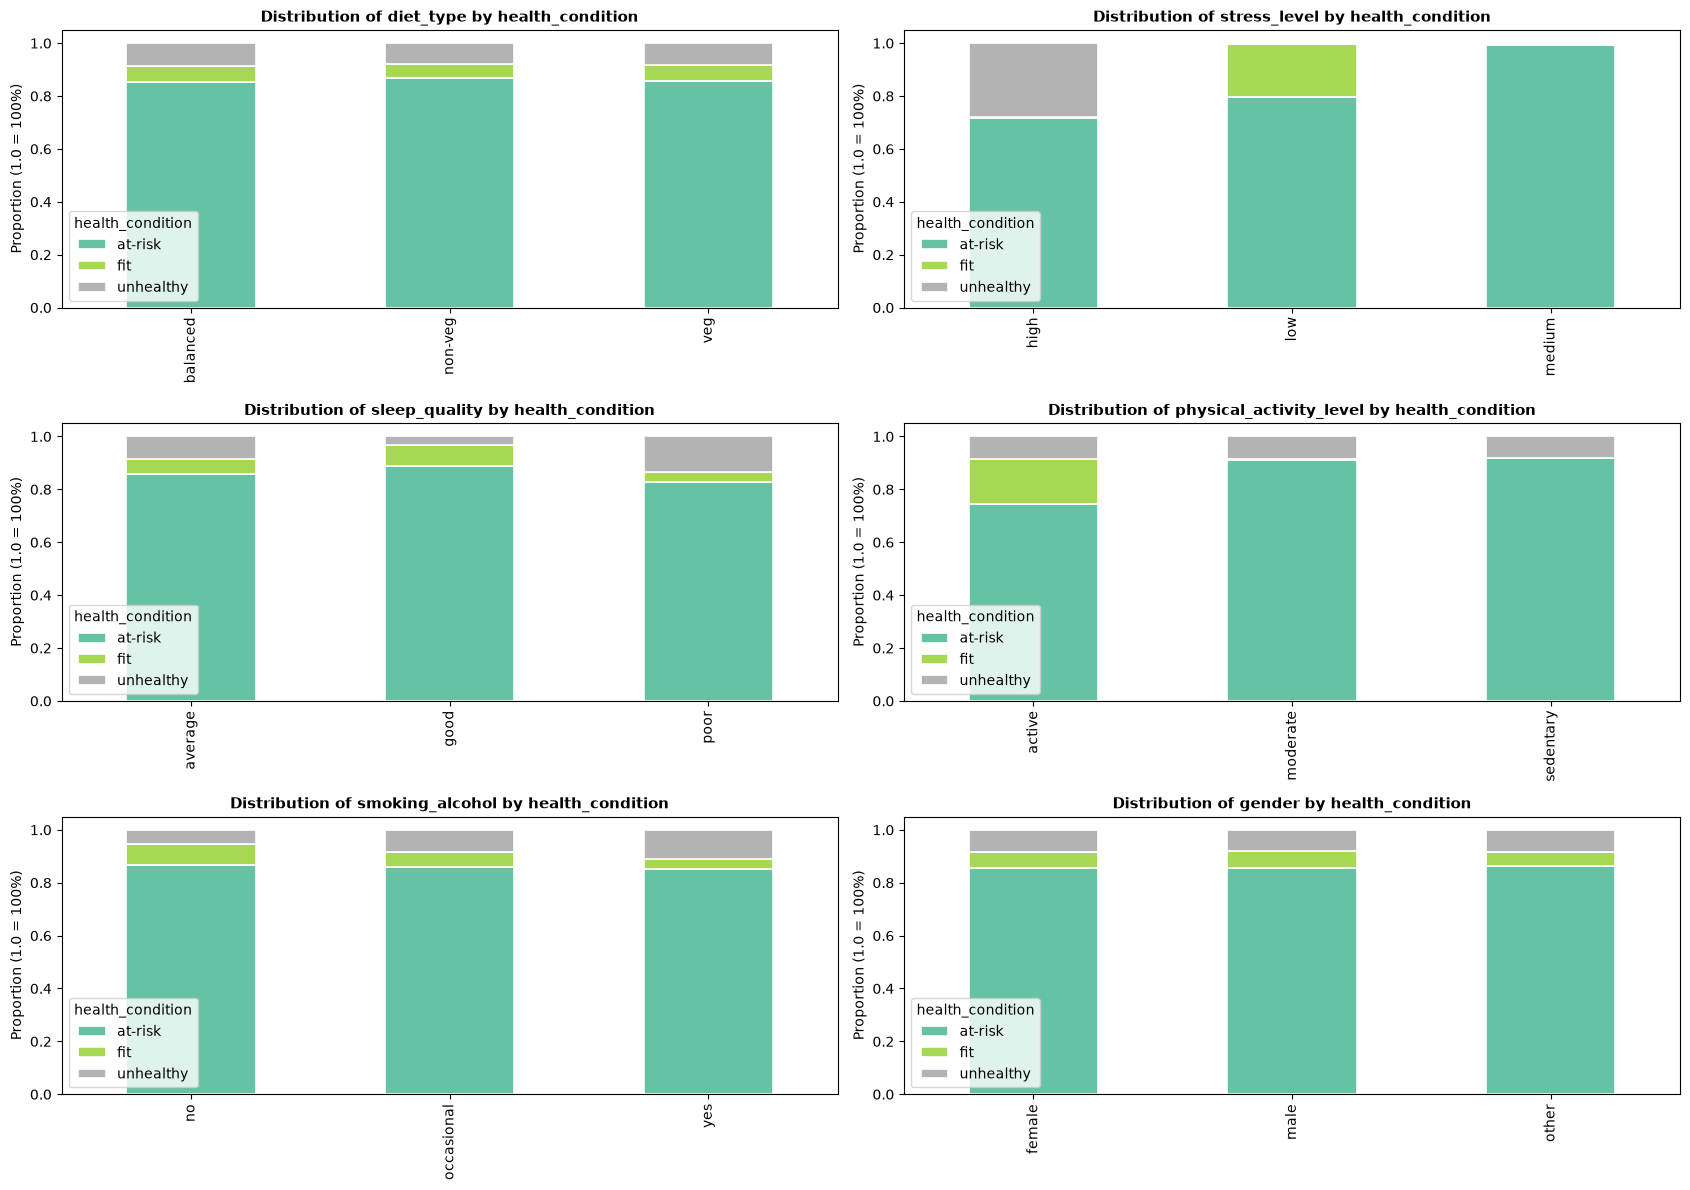

In [23]:
visualiser.plot_count(cats, target)